In [2]:
from src.deeptransyt.main import main as run_deeptransyt

sample_inchis = [
    "InChI=1S/C3H7NO3/c4-2(1-5)3(6)7/h2,5H,1,4H2,(H,6,7)/t2-/m0/s1", #L-serine
    #"InChI=1S/C5H11NO2S/c1-9-3-2-4(6)5(7)8/h4H,2-3,6H2,1H3,(H,7,8)/t4-/m0/s1" #methionine
    #"InChI=1S/C4H6O4/c5-3(6)1-2-4(7)8/h1-2H2,(H,5,6)(H,7,8)", #succinic acid
    # "InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)", #acetic acid
    # "InChI=1S/C6H12O6/c7-1-2-3(8)4(9)5(10)6(11)12-2/h2-11H,1H2/t2-,3-,4+,5-,6?/m1/s1", #glucose
    # "InChI=1S/Ca", #calcium
    # "InChI=1S/C3H7NO2/c1-2(4)3(5)6/h2H,4H2,1H3 ,(H,5,6)/t2-/m0/s1", #alanine
    # "InChI=1S/C5H9NO4/c6-3(5(9)10)1-2-4(7)8/h3H,1-2,6H2,(H,7,8)(H,9,10)/t3-/m0/s1" #glutamate
]

df_predictions = run_deeptransyt(output_dir="results", input_file="data/genome_test.txt")
df_predictions

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 2/2 [03:41<00:00, 110.52s/it]
2025-02-28 21:29:29,318 - INFO - Time taken for encodings generation: 221 seconds
2025-02-28 21:29:29,710 - INFO - All predictions saved to results\final_predictions.csv


,Accession,Binary_Predictions,Family_confidence,Predicted_Family,SubFamily_confidence,Predicted_SubFamily
0,b0010,0.999073,0.999816,2.A.96,0.999636,2.A.96.1
1,b2683,0.993821,0.997202,2.A.78,0.187745,-


If you have the embeddings already generated you can simply run the pipeline by passing the embeddings and the corresponding labels as follows:

In [3]:
from src.deeptransyt.main import main as run_deeptransyt

df_predictions = run_deeptransyt(output_dir="results", embeddings_file= "results/genome_test_embeddings.npy", binary_threshold=0.5)
df_predictions

2025-02-28 21:29:58,786 - INFO - Loading existing embeddings...
2025-02-28 21:29:59,166 - INFO - All predictions saved to results\final_predictions.csv


,Accession,Binary_Predictions,Family_confidence,Predicted_Family,SubFamily_confidence,Predicted_SubFamily
0,b0010,0.999073,0.999816,2.A.96,0.999636,2.A.96.1
1,b2683,0.993821,0.997202,2.A.78,0.187745,-


In [ ]:
pip uninstall deeptransyt -y
pip install -e .

In [1]:
import deeptransyt
print(deeptransyt.__version__)

0.0.12


In [3]:
df_test = df_predictions.fillna("-")
for x, y in enumerate(df_test["Family_Description"]):
    #print(y)
    if "Symport" in y:
        #print(df_predictions.iloc[x], "\n")
        #print("reaction: ", "sub1(in) + sub2(in) <-> sub1(out) + sub2(out)")
        #for z in df_predictions["Associated ChEBIs"].iloc[x].split(", "):
           # print("reaction: ", z ,"(in) + sub2(in) <->", z,"(out) + sub2(out)")
        pass
    # if "Antiport" in y:
        #print(df_predictions.iloc[x], "\n")
        #print("reaction: ", "sub1(in) + sub2(out) <-> sub1(out) + sub2(in)")
        pass
    if "Uniport" in y:
        #print(df_predictions.iloc[x], "\n")
        #print("reaction: ", "sub(in) <-> sub(out)") 
        pass
    if "PTS" in y: 
        #print(df_predictions.iloc[x], "\n")          irreversible
        #print("reaction: ", "sub(in) + PEP(out) -> sub-P(out) + Pyr(out)")
        pass
    if "ABC" in y:
        print(df_predictions.iloc[x])          #irreversible
        #print("reaction: ", "ATP(out) + sub(in) + H2O(out) -> ADP(out) + sub(out) + Pi(out) + H+(out)")
        for z in df_predictions["Associated ChEBIs"].iloc[x].split(", "):
            print("reaction: ", z ,"(in) + ATP(out) + H2O(out) ->", z,"(out) + ADP(out) + Pi(out) + H+(out)", "\n")  


Accession                                                           b0067
Binary_Predictions                                               0.998933
Family_confidence                                                0.999095
Predicted_Family                                                    3.A.1
SubFamily_confidence                                             0.951665
Predicted_SubFamily                                              3.A.1.19
Subs_confidence                                                  0.868014
Predicted_substrate                                                 Other
Family_Description             The ATP-binding Cassette (ABC) Superfamily
Associated ChEBIs       CHEBI:9569, CHEBI:9533, CHEBI:9530, CHEBI:9335...
Name: 65, dtype: object
reaction:  CHEBI:9569 (in) + ATP(out) + H2O(out) -> CHEBI:9569 (out) + ADP(out) + Pi(out) + H+(out) 

reaction:  CHEBI:9533 (in) + ATP(out) + H2O(out) -> CHEBI:9533 (out) + ADP(out) + Pi(out) + H+(out) 

reaction:  CHEBI:9530 (in) + ATP

In [ ]:
import re

# Filter entries with non-null InChI
filtered_df = transport_df[transport_df['inchi'].notnull()].copy()

# Normalize and split 'genes' into multiple rows
def normalize_and_split_genes(genes):
    # Replace conjunctions with a single delimiter (e.g., ",")
    genes_normalized = re.sub(r'\s+(and|or)\s+', ',', genes)
    # Split by the delimiter
    return genes_normalized.split(',')

# Apply normalization and splitting, then explode into rows
filtered_df['genes'] = filtered_df['genes'].apply(normalize_and_split_genes)
filtered_df = filtered_df.explode('genes')

# Remove any extra whitespace in 'genes'
filtered_df['genes'] = filtered_df['genes'].str.strip()

# Keep only the relevant columns
result_df = filtered_df[['genes', 'inchi']].reset_index(drop=True)

# Display the resulting DataFrame
result_df

,genes,inchi
0,b0241,InChI=1S/C7H14N2O4/c8-4(6(10)11)2-1-3-5(9)7(12...
1,b0929,InChI=1S/C7H14N2O4/c8-4(6(10)11)2-1-3-5(9)7(12...
2,b1377,InChI=1S/C7H14N2O4/c8-4(6(10)11)2-1-3-5(9)7(12...
3,b2215,InChI=1S/C7H14N2O4/c8-4(6(10)11)2-1-3-5(9)7(12...
4,b0241,InChI=1S/C9H8O3/c10-8-3-1-2-7(6-8)4-5-9(11)12/...
...,...,...
1096,b3199,InChI=1S/C112H208N3O42P3/c1-7-13-19-25-31-37-3...
1097,b3201,InChI=1S/C112H208N3O42P3/c1-7-13-19-25-31-37-3...
1098,b3200,InChI=1S/C112H208N3O42P3/c1-7-13-19-25-31-37-3...
1099,b0054,InChI=1S/C112H208N3O42P3/c1-7-13-19-25-31-37-3...


In [ ]:
inchi_list = list(set(result_df["inchi"].tolist()))
gene_list = list(set(result_df["genes"].tolist()))

df_predictions, substrate_list = run_deeptransyt(output_dir="results", embeddings_file= "data/k-12.npy", labels_file= "data/accessions.npy", substrates_inchis=inchi_list)

2025-01-13 17:26:47,100 - INFO - Loading existing encodings and labels
2025-01-13 17:26:47,980 - INFO - All predictions saved to results\final_predictions.csv
[17:26:47] Cannot assign bond directions!
[17:26:48] WARNING: not removing hydrogen atom without neighbors
[17:26:48] WARNING: not removing hydrogen atom without neighbors
[17:26:48] WARNING:  Problems/mismatches: Mobile-H( Proton balance: Does not match)

Some weights of the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSeq

In [ ]:
substrate_list

,Accession,Substrate,Prediction Value
0,b0005,InChI=1S/C6H9N3O2/c7-5(6(10)11)1-4-2-8-3-9-4/h...,0.016514
1,b0005,"InChI=1S/C4H9NO3/c1-2(6)3(5)4(7)8/h2-3,6H,5H2,...",0.009534
2,b0005,InChI=1S/C9H14N3O7P/c10-7-1-2-12(9(14)11-7)8-3...,0.023748
3,b0005,"InChI=1S/CH4O3S/c1-5(2,3)4/h1H3,(H,2,3,4)",0.084543
4,b0005,InChI=1S/C10H14N5O7P/c11-10-13-8-7(9(17)14-10)...,0.015051
...,...,...,...
265345,b4400,InChI=1S/C12H24N2O7/c13-7(12(20)21)3-1-2-4-14-...,0.130343
265346,b4400,InChI=1S/C51H74O2/c1-38(2)20-13-21-39(3)22-14-...,0.035037
265347,b4400,InChI=1S/C18H34O2/c1-2-3-4-5-6-7-8-9-10-11-12-...,0.118047
265348,b4400,InChI=1S/C5H10O5/c6-2-1-10-5(9)4(8)3(2)7/h2-9H...,0.129909


In [ ]:
filtered_predictions = substrate_list[substrate_list['Accession'].isin(gene_list)].copy()
filtered_predictions

,Accession,Substrate,Prediction Value
183,b0007,InChI=1S/C6H9N3O2/c7-5(6(10)11)1-4-2-8-3-9-4/h...,0.215487
184,b0007,"InChI=1S/C4H9NO3/c1-2(6)3(5)4(7)8/h2-3,6H,5H2,...",0.517756
185,b0007,InChI=1S/C9H14N3O7P/c10-7-1-2-12(9(14)11-7)8-3...,0.244363
186,b0007,"InChI=1S/CH4O3S/c1-5(2,3)4/h1H3,(H,2,3,4)",0.141033
187,b0007,InChI=1S/C10H14N5O7P/c11-10-13-8-7(9(17)14-10)...,0.184611
...,...,...,...
263698,b4356,InChI=1S/C12H24N2O7/c13-7(12(20)21)3-1-2-4-14-...,0.111295
263699,b4356,InChI=1S/C51H74O2/c1-38(2)20-13-21-39(3)22-14-...,0.007398
263700,b4356,InChI=1S/C18H34O2/c1-2-3-4-5-6-7-8-9-10-11-12-...,0.124082
263701,b4356,InChI=1S/C5H10O5/c6-2-1-10-5(9)4(8)3(2)7/h2-9H...,0.091691


In [ ]:
filtered_df = filtered_predictions.merge(
    result_df,
    how='inner',  
    left_on=['Accession', 'Substrate'],
    right_on=['genes', 'inchi']
)

filtered_df = filtered_df.drop(columns=['genes', 'inchi'])
filtered_df

,Accession,Substrate,Prediction Value
0,b0007,"InChI=1S/C2H5NO2/c3-1-2(4)5/h1,3H2,(H,4,5)/p-1",0.194001
1,b0019,InChI=1S/Na/q+1,0.070648
2,b0040,"InChI=1S/C7H15NO3/c1-8(2,3)5-6(9)4-7(10)11/h6,...",0.238656
3,b0054,InChI=1S/C112H208N3O42P3/c1-7-13-19-25-31-37-3...,0.067406
4,b0089,InChI=1S/C95H156N8O28P2/c1-58(2)30-19-31-59(3)...,0.036241
...,...,...,...
973,b4289,"InChI=1S/C6H8O7/c7-3(8)1-6(13,5(11)12)2-4(9)10...",0.129282
974,b4290,"InChI=1S/C6H8O7/c7-3(8)1-6(13,5(11)12)2-4(9)10...",0.130075
975,b4311,"InChI=1S/C11H19NO9/c1-4(14)12-7-5(15)2-11(20,1...",0.061225
976,b4321,InChI=1S/C6H10O7/c7-1-2(8)3(9)4(10)5(11)6(12)1...,0.424220


In [ ]:
import json
from collections import defaultdict

file_path = 'iml1515.json' 
with open(file_path, 'r') as file:
    model_data = json.load(file)

reactions = model_data.get('reactions', [])

pathway_genes = defaultdict(set)

for reaction in reactions:
    subsystem = reaction.get('subsystem', 'Unknown Subsystem')
    gene_rule = reaction.get('gene_reaction_rule', '')
    if gene_rule:
        genes = gene_rule.replace(' and ', ' ').replace(' or ', ' ').split()
        pathway_genes[subsystem].update(genes)

sorted_pathway_genes = {
    pathway: sorted(genes, key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
    for pathway, genes in pathway_genes.items()
}

for pathway, genes in sorted_pathway_genes.items():
    print(f"Pathway: {pathway}")
    print(f"Ordered Genes: {', '.join(genes)}\n")

Pathway: Nucleotide Salvage Pathway
Ordered Genes: s0001, b0030, b0049, b0099, b0125, b0160, b0171, b0238, b0337, b0383, b0469, b0474, b0477, b0480, b0639, b0675, b0684, (b0684, (b0849, b0905, b0910, b0980, b1007, b1008, b1009, b1010, b1011, b1012, b1025, b1064), b1098, b1134, b1238, b1285, b1341, b1489, b1490, b1535, b1539, b1623, b1654), b1759, b1794, b1854, b1865, b1982, b2065, b2066, b2143, b2146, b2147, b2173, ((b2234, (b2234, b2235), b2235)), b2251, b2291, b2361, b2407, b2498, b2518, b2582), (b2582, (b2675, ((b2675, b2676), b2676)), b2727, b2744, b2781, b2827, b2866, b2867, b2868, b2883, b2895, (b2895, b2918, b2954, b3032, b3034, b3248, b3397, b3399, b3590, b3610), b3614, b3640, b3648, b3665, (b3781, b3806, b3831, (b3924, b4055, b4129, b4161, b4173, b4213, b4237), b4238), b4238, b4352, b4374, b4382, b4384, b4394

Pathway: Tyrosine, Tryptophan, and Phenylalanine Metabolism
Ordered Genes: b0388, b0754, b0908, b0928, b1260, b1261, b1262, b1263, b1264, b1463, b1692, b1693, b1704, b23

In [ ]:
import json
import pandas as pd

file_path = 'iml1515.json' 
with open(file_path, 'r') as file:
    model_data = json.load(file)

gff_file = 'gff_k12.gff'  
gff_data = []

with open(gff_file, 'r') as gff:
    for line in gff:
        if line.startswith("#"):
            continue  
        columns = line.strip().split("\t")
        if len(columns) < 9 or "gene" not in columns[2]: 
            continue
        attributes = {kv.split("=")[0]: kv.split("=")[1] for kv in columns[8].split(";") if "=" in kv}
        gff_data.append({
            "locus_tag": attributes.get("locus_tag"),
            "start": int(columns[3]),
            "end": int(columns[4]),
            "strand": columns[6],
            "gene_name": attributes.get("Name", ""),
        })

gff_df = pd.DataFrame(gff_data)

reactions = model_data.get('reactions', [])
pathway_genes = {}

for reaction in reactions:
    subsystem = reaction.get('subsystem', 'Unknown Subsystem')
    gene_rule = reaction.get('gene_reaction_rule', '')
    if gene_rule:
        genes = gene_rule.replace(' and ', ' ').replace(' or ', ' ').split()
        for gene in genes:
            if gene not in pathway_genes:
                pathway_genes[gene] = []
            pathway_genes[gene].append(subsystem)

gff_df['pathways'] = gff_df['locus_tag'].apply(lambda gene: ', '.join(pathway_genes.get(gene, [])))
gff_df_final = gff_df[gff_df["pathways"] != ""]
gff_df_final

,locus_tag,start,end,strand,gene_name,pathways
1,b0002,337,2799,+,thrA,"Threonine and Lysine Metabolism, Threonine and..."
2,b0003,2801,3733,+,thrB,"Threonine and Lysine Metabolism, Glycine and S..."
3,b0004,3734,5020,+,thrC,Threonine and Lysine Metabolism
6,b0007,6529,7959,-,yaaJ,"Transport, Inner Membrane, Transport, Inner Me..."
7,b0008,8238,9191,+,talB,Pentose Phosphate Pathway
...,...,...,...,...,...,...
4670,b4386,4623101,4624117,-,lplA,"Cofactor and Prosthetic Group Biosynthesis, Co..."
4672,b4388,4624895,4625863,+,serB,Glycine and Serine Metabolism
4674,b4390,4627315,4628547,+,nadR,Cofactor and Prosthetic Group Biosynthesis
4676,b4392,4630733,4632670,+,slt,"Murein Recycling, Murein Recycling, Murein Rec..."


In [ ]:
import pandas as pd

genomic_df = gff_df_final

genomic_df['pathways'] = genomic_df['pathways'].str.split(", ")
genomic_df = genomic_df.explode('pathways')

pathway_distances = {}

grouped = genomic_df.groupby('pathways')

for pathway, group in grouped:
    sorted_group = group.sort_values(by='start')

    distances = sorted_group['start'].diff().dropna()
    pathway_distances[pathway] = distances.tolist()

distance_df = pd.DataFrame.from_dict(pathway_distances, orient='index').transpose()

print("Summary of distances between genes in each pathway:")
distance_df.describe()

Summary of distances between genes in each pathway:


C:\Users\gonca\AppData\Local\Temp\ipykernel_27756\4053939527.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genomic_df['pathways'] = genomic_df['pathways'].str.split(", ")


,Alanine and Aspartate Metabolism,Alternate Carbon Metabolism,Anaplerotic Reactions,Arginine and Proline Metabolism,Biomass and maintenance functions,Cell Envelope Biosynthesis,Citric Acid Cycle,Cofactor and Prosthetic Group Biosynthesis,Cysteine Metabolism,Folate Metabolism,...,Pyruvate Metabolism,Threonine and Lysine Metabolism,Transport,Tryptophan,Tyrosine,Unassigned,Valine,and Isoleucine Metabolism,and Phenylalanine Metabolism,tRNA Charging
count,13.000000,316.000000,1.100000e+01,48.000000,1.0,184.000000,2.600000e+01,267.000000,19.000000,1.000000e+01,...,2.300000e+01,29.000000,1843.000000,36.000000,36.000000,34.000000,1.700000e+01,1.700000e+01,36.000000,0.0
mean,282259.846154,14532.626582,2.631955e+05,92808.104167,3708734.0,22167.885870,1.635615e+05,17295.913858,222641.105263,4.004704e+05,...,1.701083e+05,150837.655172,2488.785676,107305.805556,107305.805556,117406.676471,2.463686e+05,2.463686e+05,107305.805556,NaN
std,279247.678959,26716.305437,3.189120e+05,155257.099465,NaN,73502.939652,3.086160e+05,35918.596566,273078.054586,4.564034e+05,...,2.931818e+05,193900.042672,9852.388259,186282.803993,186282.803993,170222.599495,5.295744e+05,5.295744e+05,186282.803993,NaN
min,0.000000,0.000000,0.000000e+00,0.000000,3708734.0,0.000000,0.000000e+00,0.000000,605.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,NaN
25%,89496.000000,0.000000,2.532400e+04,1026.250000,3708734.0,0.000000,9.250000e+01,0.000000,6183.000000,3.911000e+03,...,1.285000e+03,8097.000000,0.000000,0.000000,0.000000,1639.000000,0.000000e+00,0.000000e+00,0.000000,NaN
50%,169055.000000,1408.000000,2.320130e+05,28720.500000,3708734.0,0.000000,1.822000e+03,1539.000000,106989.000000,2.811820e+05,...,2.029000e+03,85372.000000,0.000000,1204.000000,1204.000000,39542.500000,1.091000e+03,1.091000e+03,1204.000000,NaN
75%,556701.000000,16369.750000,3.316525e+05,134275.750000,3708734.0,997.250000,1.314318e+05,16356.500000,386553.000000,6.554210e+05,...,1.952475e+05,192068.000000,0.000000,183044.250000,183044.250000,196757.000000,2.127790e+05,2.127790e+05,183044.250000,NaN
max,827473.000000,181404.000000,1.022126e+06,824313.000000,3708734.0,496984.000000,1.078222e+06,277721.000000,768681.000000,1.196022e+06,...,1.022961e+06,760845.000000,98678.000000,689940.000000,689940.000000,805529.000000,1.799954e+06,1.799954e+06,689940.000000,NaN


In [ ]:
import numpy as np
genomic_df['pathways'] = genomic_df['pathways'].str.split(", ")
genomic_df = genomic_df.explode('pathways')

pathway_p_values = {}

n_permutations = 1000

def calculate_mean_distance(group):
    sorted_group = group.sort_values(by='start')
    distances = sorted_group['start'].diff().dropna()
    return distances.mean() if not distances.empty else np.nan

observed_distances = {}
for pathway, group in genomic_df.groupby('pathways'):
    observed_distances[pathway] = calculate_mean_distance(group)

for pathway, observed_distance in observed_distances.items():
    if np.isnan(observed_distance):
        continue  

    random_distances = []
    for _ in range(n_permutations):
        shuffled = genomic_df.copy()
        shuffled['pathways'] = np.random.permutation(shuffled['pathways'])
        shuffled_group = shuffled[shuffled['pathways'] == pathway]
        random_distances.append(calculate_mean_distance(shuffled_group))

    random_distances = np.array(random_distances)
    p_value = (np.sum(random_distances <= observed_distance) + 1) / (n_permutations + 1)
    pathway_p_values[pathway] = p_value

significant_pathways = {k: v for k, v in pathway_p_values.items() if v < 0.05}
print("Significant pathways (p < 0.05):")
print(significant_pathways)

Significant pathways (p < 0.05):
{'Cell Envelope Biosynthesis': 0.000999000999000999, 'Glycerophospholipid Metabolism': 0.000999000999000999, 'Histidine Metabolism': 0.000999000999000999, 'Membrane Lipid Metabolism': 0.000999000999000999, 'Murein Biosynthesis': 0.000999000999000999, 'Outer Membrane Porin': 0.000999000999000999, 'Oxidative Phosphorylation': 0.000999000999000999, 'Transport': 0.000999000999000999, 'Tryptophan': 0.023976023976023976, 'Tyrosine': 0.027972027972027972, 'and Phenylalanine Metabolism': 0.03796203796203796}


C:\Users\gonca\AppData\Local\Temp\ipykernel_27756\1063835701.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_pathways_df, x='p_value', y='Pathway', palette='viridis')


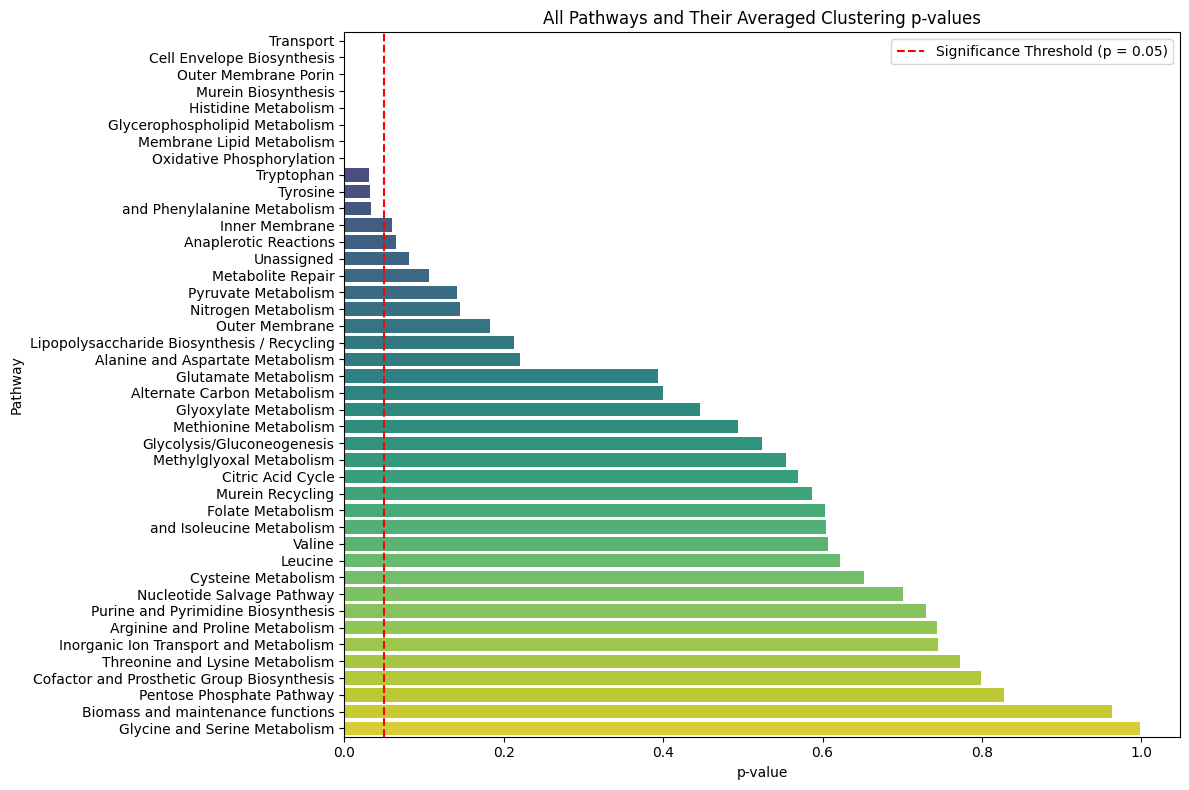

In [ ]:
n_permutations = 1000
n_runs = 5 

averaged_p_values = {}

for pathway, observed_distance in observed_distances.items():
    if np.isnan(observed_distance):
        continue

    cumulative_p_value = 0 
    for run in range(n_runs):
        random_distances = []
        for _ in range(n_permutations):
            shuffled = genomic_df.copy()
            shuffled['pathways'] = np.random.permutation(shuffled['pathways'])
            shuffled_group = shuffled[shuffled['pathways'] == pathway]
            random_distances.append(calculate_mean_distance(shuffled_group))

        random_distances = np.array(random_distances)
        p_value = (np.sum(random_distances <= observed_distance) + 1) / (n_permutations + 1)
        cumulative_p_value += p_value

    averaged_p_values[pathway] = cumulative_p_value / n_runs

all_pathways_df = pd.DataFrame(list(averaged_p_values.items()), columns=['Pathway', 'p_value'])
all_pathways_df = all_pathways_df.sort_values(by='p_value')

plt.figure(figsize=(12, 8))
sns.barplot(data=all_pathways_df, x='p_value', y='Pathway', palette='viridis')
plt.axvline(x=0.05, color='red', linestyle='--', label='Significance Threshold (p = 0.05)')
plt.xlabel('p-value')
plt.ylabel('Pathway')
plt.title('All Pathways and Their Averaged Clustering p-values')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\gonca\AppData\Local\Temp\ipykernel_27756\3488886232.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=significant_pathways_df, x='p_value', y='Pathway', palette='viridis')


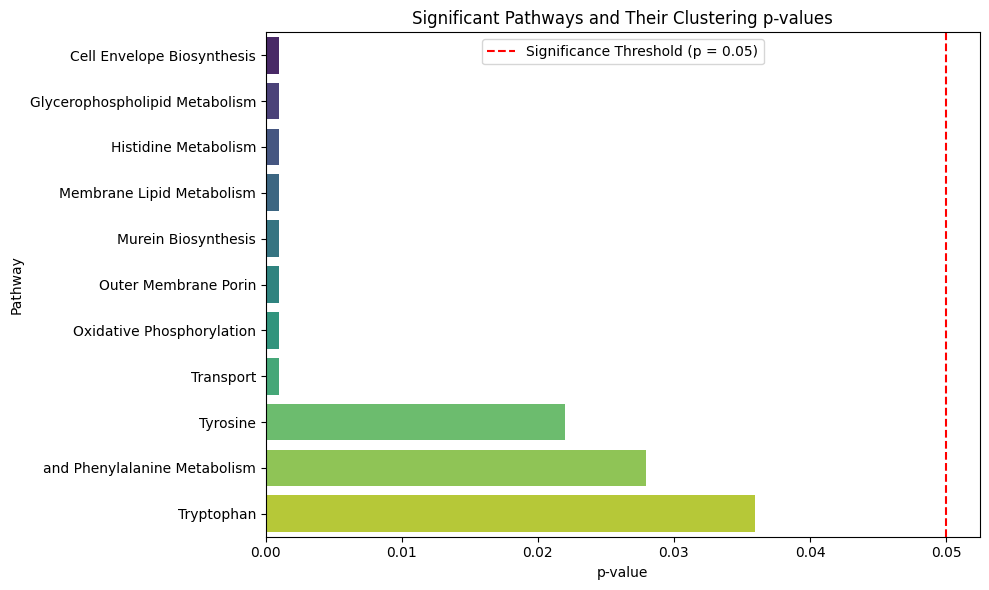

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

significant_pathways = {
    'Cell Envelope Biosynthesis': 0.000999000999000999,
    'Glycerophospholipid Metabolism': 0.000999000999000999,
    'Histidine Metabolism': 0.000999000999000999,
    'Membrane Lipid Metabolism': 0.000999000999000999,
    'Murein Biosynthesis': 0.000999000999000999,
    'Outer Membrane Porin': 0.000999000999000999,
    'Oxidative Phosphorylation': 0.000999000999000999,
    'Transport': 0.000999000999000999,
    'Tryptophan': 0.03596403596403597,
    'Tyrosine': 0.02197802197802198,
    'and Phenylalanine Metabolism': 0.027972027972027972
}

significant_pathways_df = pd.DataFrame(list(significant_pathways.items()), columns=['Pathway', 'p_value'])

significant_pathways_df = significant_pathways_df.sort_values(by='p_value')

plt.figure(figsize=(10, 6))
sns.barplot(data=significant_pathways_df, x='p_value', y='Pathway', palette='viridis')
plt.axvline(x=0.05, color='red', linestyle='--', label='Significance Threshold (p = 0.05)')
plt.xlabel('p-value')
plt.ylabel('Pathway')
plt.title('Significant Pathways and Their Clustering p-values')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\gonca\AppData\Local\Temp\ipykernel_27756\4151210337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_pathways_df, x='p_value', y='Pathway', palette='viridis')


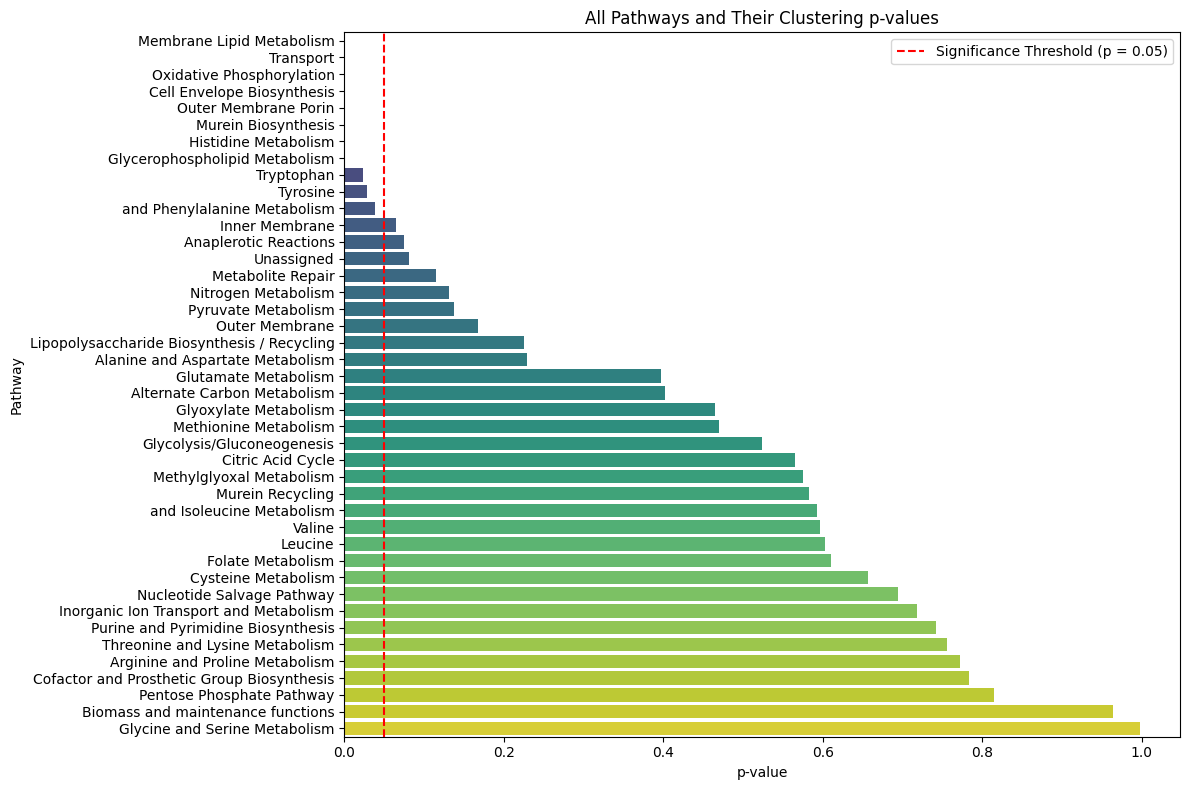

In [ ]:
all_pathways_df = pd.DataFrame(list(pathway_p_values.items()), columns=['Pathway', 'p_value'])

all_pathways_df = all_pathways_df.sort_values(by='p_value')

plt.figure(figsize=(12, 8))
sns.barplot(data=all_pathways_df, x='p_value', y='Pathway', palette='viridis')
plt.axvline(x=0.05, color='red', linestyle='--', label='Significance Threshold (p = 0.05)')
plt.xlabel('p-value')
plt.ylabel('Pathway')
plt.title('All Pathways and Their Clustering p-values')
plt.legend()
plt.tight_layout()
plt.show()